In [4]:
from msi_visual.extraction import get_extraction_mz_list
from msi_visual.normalization import spatial_total_ion_count, total_ion_count, median_ion
from msi_visual.supervised.annotations import get_img, get_visualization, get_dataset
from scipy.stats import mannwhitneyu
import numpy as np
import tqdm
from argparse import Namespace
from pathlib import Path
array = np.array

path = r"E:\MSImaging-data\_msi_visual\Extractions\atlas_verification"
extraction_args = eval(
    open(
        Path(path) /
        "args.txt").read())
extraction_mzs = extraction_args.mzs

paths = [(path + "\\0.npy", 1), (path + "\\2.npy", 0), (path + "\\1.npy", 2), (path + "\\3.npy", 3)]


X, y, label_encoder = get_dataset(r"../scripts/graph_data/NRL4485-s2_reannotation_23-12-24_PAHJ.json", paths, subsample=5, normalization=total_ion_count)
y = np.array(y)

using normalization <function total_ion_count at 0x00000284066D6840>
using normalization <function total_ion_count at 0x00000284066D6840>
using normalization <function total_ion_count at 0x00000284066D6840>
using normalization <function total_ion_count at 0x00000284066D6840>


In [ ]:
from xgboost import XGBClassifier
from collections import defaultdict
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import StratifiedKFold
import shap
import numpy as np

def train_model(X, y, num_folds = 10):
    # Number of folds
    kf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

    # List to store mean SHAP values for each fold
    mean_shap_list = []
    category_shaps = defaultdict(list)
    for train_index, test_index in kf.split(X, y):
        # Split data
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        # Compute sample weights
        sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

        #Train XGBoost model
        xgb_model1 = XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=10,
            random_state=42
        )
        xgb_model1.fit(X_train, y_train, sample_weight=sample_weights)

        #Train XGBoost model
        xgb_model2 = XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=10,
            random_state=42
        )
        xgb_model2.fit(X_train, y_train)



        # Compute SHAP values
        explainer = shap.Explainer(xgb_model1)
        shap_values1 = explainer(X_test).values  # Shape: (num_samples, num_features)

        # Compute SHAP values
        explainer2 = shap.Explainer(xgb_model2)
        shap_values2 = explainer2(X_test).values  # Shape: (num_samples, num_features)



        from sklearn.metrics import accuracy_score

        # Predictions
        y_pred1 = xgb_model1.predict(X_test)
        y_pred2 = xgb_model2.predict(X_test)


        for label in np.unique(y_test):
            category_indices = [i for i in range(len(y_test)) if y_test[i] == label]

            category_y_test = y_test[category_indices]
            category_y_pred1 = y_pred1[category_indices]
            category_y_pred2 = y_pred2[category_indices]
            category_accuracy1 = accuracy_score(category_y_test, category_y_pred1)
            category_accuracy2 = accuracy_score(category_y_test, category_y_pred2)
            print(f"Accuracy for category {label_encoder.inverse_transform([label])[0]}: {category_accuracy1}")
            print(f"Accuracy for category {label_encoder.inverse_transform([label])[0]}: {category_accuracy2}")



            category_shap = shap_values1[category_indices, :]
            #print(category_shap.shape)
            category_shap = category_shap[:, :, label]
            category_shap = np.mean(category_shap, axis=0)

            category_shap2 = shap_values2[category_indices, :]
            #print(category_shap.shape)
            category_shap2 = category_shap2[:, :, label]
            category_shap2 = np.mean(category_shap2, axis=0)



            category_shaps[label].append((category_shap, category_accuracy1, category_shap2, category_accuracy2))

train_model(X, y, num_folds = 10)

c:\Users\PahnkeLab\miniconda3\envs\maldi\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\PahnkeLab\miniconda3\envs\maldi\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 6 members, which is less than n_splits=10.
  warnings.warn(


KeyboardInterrupt: 

In [4]:
# Compute mean absolute SHAP values to find important features
means = np.mean(mean_shap_list, axis=0)
print(means.shape)

(880, 123)


In [16]:
mean_shap = np.float32(means)
print(mean_shap.shape)
for i in range(mean_shap.shape[1]):
    x = mean_shap[:, i]
    
    category_shap_values = np.argsort(x)
    category_shap_values = category_shap_values[-50 :]
    mzs = np.float32([extraction_mzs[index] for index in category_shap_values])
    category = label_encoder.inverse_transform([i])[0]
    if "PLQ" in category:
        print(x[category_shap_values])
        print(category, mzs)
    

NameError: name 'means' is not defined

In [37]:
top_mzs = {}
for i in category_shaps:
    category = label_encoder.inverse_transform([i])[0]
    x = np.mean(np.array(category_shaps[i]), axis=0)
    category_shap_values = np.argsort(x)
    category_shap_values = category_shap_values[-50 :]
    mzs = np.float32([extraction_mzs[index] for index in category_shap_values])
    top_mzs[category] = mzs
    if "PLQ" in category:
        print(category, list(mzs))
    

import joblib
joblib.dump(top_mzs, "shap_mzs_tic.joblib")



PLQ_ARTEFACT_ARTEFACT [760.51276, 1003.5379, 806.544, 806.554, 1112.8967, 892.56714, 763.51, 771.63745, 911.6154, 884.5869, 700.5277, 752.53, 721.48, 817.57947, 673.47974, 878.4972, 1003.47064, 822.5419, 866.5073, 905.6217, 761.5158, 810.528, 878.57025, 892.6172, 574.2103, 838.559, 858.52057, 891.63934, 848.6621, 858.5195, 904.61707, 1180.7719, 762.50574, 842.66187, 765.5666, 558.06476, 965.5173, 1207.7844, 834.52826, 1207.7594, 786.52856, 865.50305, 886.553, 716.5782, 715.5755, 857.5171, 1180.7394, 540.0534, 480.3087, 1179.7308]


['shap_mzs_tic.joblib']

In [60]:
top_mzs = {}
for i in category_shaps:
    category = label_encoder.inverse_transform([i])[0]

    shaps = []
    for shap1, acc1, shap2, acc2 in category_shaps[i]:
        if acc1 > acc2 and acc1 >= 0.3:
            shaps.append(shap1)
        elif acc2 >= acc1 and acc2 > 0.3:
            shaps.append(shap2)

    x = np.mean(np.array(shaps), axis=0)
    category_shap_values = np.argsort(x)
    category_shap_values = category_shap_values
    mzs = np.float32([extraction_mzs[index] for index in category_shap_values])
    if len(shaps) == 0:
        mzs = None
    top_mzs[category] = mzs
    if "PLQ" in category:
        print(category, list(mzs))
    

import joblib
joblib.dump(top_mzs, "shap_mzs_tic.joblib")



PLQ_ARTEFACT_ARTEFACT [907.63605, 943.5343, 826.52545, 860.63745, 703.5433, 818.5721, 890.67554, 793.5162, 831.5599, 888.5797, 892.56714, 1045.5153, 818.5682, 1164.9137, 792.5468, 911.6154, 793.5751, 833.5694, 844.59326, 1133.8739, 843.6294, 848.6386, 822.6041, 845.6097, 690.50714, 1140.9175, 827.7116, 1133.8684, 873.4866, 1116.9152, 726.5434, 855.57996, 943.50726, 882.5301, 882.5277, 837.54156, 798.5193, 832.63983, 908.6161, 761.48566, 814.5577, 723.5163, 872.5183, 349.05615, 884.61884, 775.5468, 888.51685, 376.9452, 844.60614, 807.5005, 818.5109, 884.5364, 872.6362, 875.6122, 756.5613, 806.554, 534.3551, 360.97134, 812.5656, 878.4972, 851.6656, 529.31274, 866.5354, 844.64276, 859.6213, 779.51385, 822.5419, 728.5586, 842.5882, 807.5431, 749.5065, 508.33707, 835.5746, 729.5621, 837.6268, 832.51196, 885.5483, 750.51385, 1141.9343, 772.58527, 843.55774, 842.60297, 717.6144, 505.98822, 833.47864, 1114.9121, 754.57526, 888.55853, 1165.9222, 864.64417, 826.6804, 806.46234, 760.48865, 1003.5

c:\Users\PahnkeLab\miniconda3\envs\maldi\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\PahnkeLab\miniconda3\envs\maldi\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\PahnkeLab\miniconda3\envs\maldi\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\PahnkeLab\miniconda3\envs\maldi\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


['shap_mzs_tic.joblib']

In [6]:
import joblib
auc_mzs = joblib.load("auc_mzs.joblib")
top_shap_mzs = joblib.load("shap_mzs_tic.joblib")

In [97]:
k = 5000
categories = list(auc_mzs["common"].keys())
unique_mzs = auc_mzs["unique"]
common_mzs = auc_mzs["common"]

all_shap_mzs = []
all_auc_mzs = []
all_intersection_mzs = []

for category in categories:
    if top_shap_mzs[category] is None:
        top_shap_mzs[category] = []
        continue

    # Get unique and common m/z values with scores
    unique_pairs_orig = sorted(unique_mzs[category], key=lambda x: x[1], reverse=True)
    common_pairs_orig = sorted(common_mzs[category], key=lambda x: x[1], reverse=True)
    auc_pairs = sorted(unique_mzs[category] + common_mzs[category], key=lambda x: x[1], reverse=True)


    unique_pairs = [p for p in unique_pairs_orig if p[0] in top_shap_mzs[category][-50 : ]]
    common_pairs = [p for p in common_pairs_orig if p[0] in top_shap_mzs[category][-50 : ]]
    intersection_pairs = unique_pairs + common_pairs
    intersection_pairs = intersection_pairs[ : k]

    N = len(intersection_pairs)
    if N == 0:
        continue
    print(len(intersection_pairs), len(auc_pairs[ : N]), len(top_shap_mzs[category][-N :]))

    all_intersection_mzs.extend([x[0] for x in intersection_pairs])
    all_auc_mzs.extend([x[0] for x in auc_pairs[ : N]])
    all_shap_mzs.extend(top_shap_mzs[category][-N :])


all_intersection_mzs = list(set(all_intersection_mzs))
all_auc_mzs = list(set(all_auc_mzs))
all_shap_mzs = list(set(all_shap_mzs))

print(len(all_shap_mzs), len(all_auc_mzs), len(all_intersection_mzs))


5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
3 3 3
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
4 4 4
5 5 5
5 5 5
3 3 3
5 5 5
5 5 5
5 5 5
2 2 2
5 5 5
3 3 3
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
3 3 3
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
3 3 3
5 5 5
4 4 4
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
4 4 4
2 2 2
5 5 5
4 4 4
4 4 4
1 1 1
1 1 1
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
5 5 5
2 2 2
4 4 4
1 1 1
2 2 2
5 5 5
4 4 4
2 2 2
136 254 225


In [98]:
shap_indices = sorted([np.argmin(np.abs(np.float32(extraction_mzs) - mz)) for mz in all_shap_mzs])
auc_indices = sorted([np.argmin(np.abs(np.float32(extraction_mzs) - mz)) for mz in all_auc_mzs])
intersection_indices = sorted([np.argmin(np.abs(np.float32(extraction_mzs) - mz)) for mz in all_intersection_mzs])


In [99]:
from xgboost import XGBClassifier
from collections import defaultdict
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import StratifiedKFold, KFold
import shap
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder



def train_model(X, y, num_folds = 10):
    # Number of folds
    kf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)
    # List to store mean SHAP values for each fold
    mean_shap_list = []
    category_shaps = defaultdict(list)
    stats = []


    for train_index, test_index in kf.split(X, y):
        # Split data



        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        # Compute sample weights
        sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

        #Train XGBoost model
        model = XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=10,
            random_state=42
        )
        print(X_train.shape, len(y_train))
        
        le = LabelEncoder()
        
        good_indices = [i for i in range(len(X_test)) if y_test[i] in y_train]
        X_test = X_test[good_indices, :]
        y_test = y_test[good_indices]
        
        y_train = le.fit_transform(y_train)
        y_test = le.transform(y_test)


        model.fit(X_train, y_train, sample_weight=sample_weights)
        y_pred = model.predict(X_test)

        stats.append(accuracy_score(y_test, y_pred))
    return np.mean(stats)

all_acc = train_model(X[::40, :], y[::40], 2)
shap_acc = train_model(X[::40, shap_indices], y[::40], 2)
intersection_acc = train_model(X[::40, intersection_indices], y[::40], 2)
auc_acc = train_model(X[::40, auc_indices], y[::40], 2)
print(all_acc, shap_acc, auc_acc, intersection_acc)

c:\Users\PahnkeLab\miniconda3\envs\maldi\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(


(543, 880) 543
(543, 880) 543


c:\Users\PahnkeLab\miniconda3\envs\maldi\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(


(543, 136) 543
(543, 136) 543


c:\Users\PahnkeLab\miniconda3\envs\maldi\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(


(543, 225) 543
(543, 225) 543
(543, 254) 543


c:\Users\PahnkeLab\miniconda3\envs\maldi\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(


(543, 254) 543
0.7388185301238104 0.7502253742302742 0.7464558084755251 0.7473845684083491


0.7388185301238104 0.7435713818348371 0.7369064842347091 0.739774553068361


In [8]:
category_names = label_encoder.inverse_transform(y)

In [43]:
from sklearn.metrics import roc_auc_score
import joblib
import numpy as np

def get_stats(k, agg):
    auc_mzs = joblib.load("auc_mzs.joblib")
    top_shap_mzs = joblib.load("shap_mzs_tic.joblib")
    top_bayes_mzs = joblib.load("bayes_mzs.joblib")


    categories = list(auc_mzs["common"].keys())
    unique_mzs = auc_mzs["unique"]
    common_mzs = auc_mzs["common"]

    auc_scores, shap_scores, intersection_scores = [], [], []
    bayes_scores = []
    ratios = []
    for category in categories:
    #for category in ["PLQ_ARTEFACT_ARTEFACT"]:
        if top_shap_mzs[category] is None:
            top_shap_mzs[category] = []
            continue

        # Get unique and common m/z values with scores
        unique_pairs_orig = sorted(unique_mzs[category], key=lambda x: x[1], reverse=True)
        common_pairs_orig = sorted(common_mzs[category], key=lambda x: x[1], reverse=True)
        auc_pairs = sorted(unique_mzs[category] + common_mzs[category], key=lambda x: x[1], reverse=True)
        auc_mz_for_category = [x[0] for x in auc_pairs[: k]]


        intersection_mzs = [x[0] for x in auc_pairs if x[0] in top_shap_mzs[category][-k :]]
        
        
        
        # bayes_indices = sorted([np.argmin(np.abs(np.float32(extraction_mzs) - mz)) \
        #                             for mz in top_bayes_mzs[category][: k]])
        bayes_indices = [extraction_mzs.index(mz) for mz in top_bayes_mzs[category][: k]]
        

        shap_indices = sorted([np.argmin(np.abs(np.float32(extraction_mzs) - mz)) \
                               for mz in top_shap_mzs[category][-k : ]])
        auc_indices = sorted([np.argmin(np.abs(np.float32(extraction_mzs) - mz)) \
                              for mz in auc_mz_for_category])
        intersection_indices = sorted([np.argmin(np.abs(np.float32(extraction_mzs) \
                                                        - mz)) for mz \
                                                            in intersection_mzs])

        ratio = len(intersection_indices) / (1e-5 + len(auc_indices))
        

        if len(intersection_indices) < 1:
            intersection_indices = auc_indices
            #continue
        

        binary_label = np.array(category_names) == category

        if len(auc_indices) > 0:
            if agg == "min":
                auc_sum = X[:, auc_indices].min(axis=-1)
            elif agg == "max":
                auc_sum = X[:, auc_indices].max(axis=-1)
            elif agg == "mean":
                auc_sum = X[:, auc_indices].mean(axis=-1)
            elif agg == "sum":
                auc_sum = X[:, auc_indices].sum(axis=-1)

        else:
            auc_sum = np.zeros(X.shape[0])

        if len(intersection_indices) > 0:
            if agg == "min":
                intersection_sum = X[:, intersection_indices].min(axis=-1)
            elif agg == "max":
                intersection_sum = X[:, intersection_indices].max(axis=-1)
            elif agg == "mean":
                intersection_sum = X[:, intersection_indices].mean(axis=-1)
            elif agg == "sum":
                intersection_sum = X[:, intersection_indices].sum(axis=-1)
        else:
            intersection_sum = np.zeros(X.shape[0])


        if len(shap_indices) > 0:
            if agg == "min":
                shap_sum = X[:, shap_indices].min(axis=-1)
            elif agg == "max":
                shap_sum = X[:, shap_indices].max(axis=-1)
            elif agg == "mean":
                shap_sum = X[:, shap_indices].mean(axis=-1)
            elif agg == "sum":
                shap_sum = X[:, shap_indices].sum(axis=-1)

        else:
            shap_sum = np.zeros(X.shape[0])


        if len(bayes_indices) > 0:
            if agg == "min":
                bayes_sum = X[:, bayes_indices].min(axis=-1)
            elif agg == "max":
                bayes_sum = X[:, bayes_indices].max(axis=-1)
            elif agg == "mean":
                bayes_sum = X[:, bayes_indices].mean(axis=-1)
            elif agg == "sum":
                bayes_sum = X[:, bayes_indices].sum(axis=-1)

        else:
            bayes_sum = np.zeros(X.shape[0])


        intersection_sum[np.isnan(intersection_sum)] = 0
        auc_sum[np.isnan(auc_sum)] = 0
        shap_sum[np.isnan(shap_sum)] = 0
        bayes_sum[np.isnan(bayes_sum)] = 0

        auc_score = roc_auc_score(binary_label, auc_sum)
        shap_score = roc_auc_score(binary_label, shap_sum)
        intersection_score = roc_auc_score(binary_label, intersection_sum)
        bayes_score = roc_auc_score(binary_label, bayes_sum)

        auc_scores.append(auc_score)
        bayes_scores.append(bayes_score)
        shap_scores.append(shap_score)
        intersection_scores.append(intersection_score)
        ratios.append(ratio)

    return np.mean(bayes_scores), np.mean(auc_scores), np.mean(shap_scores), np.mean(intersection_scores), len(intersection_scores), np.mean(ratios)

In [57]:
category_names = label_encoder.inverse_transform(y)

result_min = {}
result_max = {}
result_mean = {}
result_sum = {}
for k in range(1, 101, 40):
    result_min[k] = get_stats(k, "min")
    result_max[k] = get_stats(k, "max")
    result_sum[k] = get_stats(k, "sum")

    


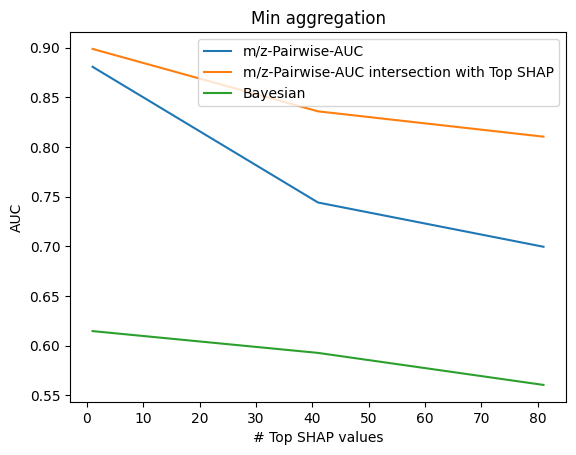

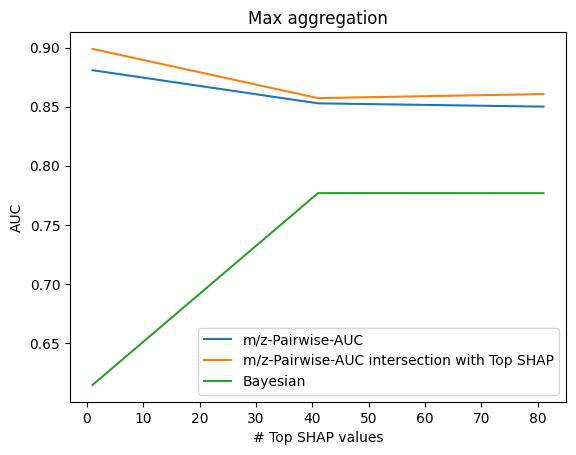

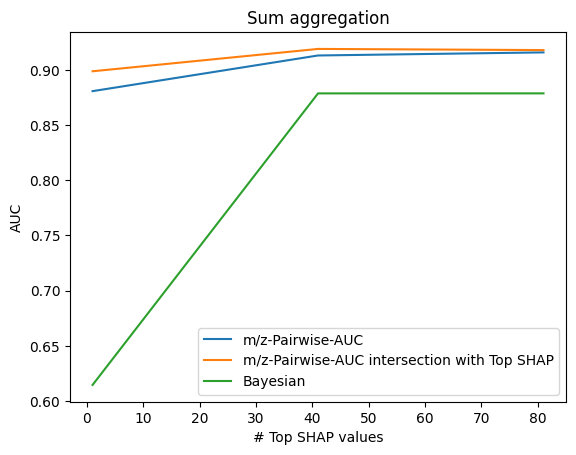

In [58]:
import matplotlib.pyplot as plt

def plot_results(data, title):
    ks = list(data.keys())
    bayes, auc, shap, inter = [x[0] for x in data.values()], [x[1] for x in data.values()], [x[2] for x in data.values()], [x[3] for x in data.values()]

    plt.plot(ks, auc, label = "m/z-Pairwise-AUC")    
    #plt.plot(ks, shap, label = "SHAP")
    plt.plot(ks, inter, label="m/z-Pairwise-AUC intersection with Top SHAP")
    plt.plot(ks, bayes, label="Bayesian")
    plt.ylabel("AUC")
    plt.xlabel("# Top SHAP values")
    plt.legend()
    plt.title(title)
    plt.show()

plot_results(result_min, "Min aggregation")
plot_results(result_max, "Max aggregation")
plot_results(result_sum, "Sum aggregation")



In [19]:
top_shap_mzs = joblib.load("shap_mzs_tic.joblib")
print(top_shap_mzs)

{'BG_ARTEFACT_ARTEFACT': array([ 859.5241 ,  746.56476,  837.55396,  303.234  ,  910.55273,
        888.5797 ,  808.5106 ,  911.5626 ,  502.28897,  738.5072 ,
        306.07837,  307.08145,  506.3239 ,  911.5585 ,  880.60657,
        844.5622 ,  909.549  ,  827.68085,  816.5753 ,  884.5364 ,
        574.2103 ,  807.5549 ,  809.5142 ,  525.2809 ,  838.6331 ,
        765.5273 ,  885.55444,  765.5266 , 1045.4775 ,  360.97134,
        479.29654,  793.5518 ,  796.5755 ,  883.5328 ,  889.6516 ,
        878.4972 ,  526.2873 ,  785.6269 ,  836.64215,  832.63983,
        814.53235,  780.58704,  825.66394,  843.6684 ,  703.5187 ,
        847.624  ,  904.61707,  865.6196 ,  858.6598 ,  755.57874,
        346.05637,  854.60474, 1141.9343 ,  730.5718 ,  819.6106 ,
       1158.9137 ,  837.54156,  863.563  ,  806.5096 ,  859.6601 ,
        866.5354 ,  751.5139 ,  535.3224 , 1086.8845 ,  875.6122 ,
        777.5271 , 1158.8726 ,  832.53357,  756.5613 , 1003.47064,
        887.55554,  864.64417,  771.5

[]


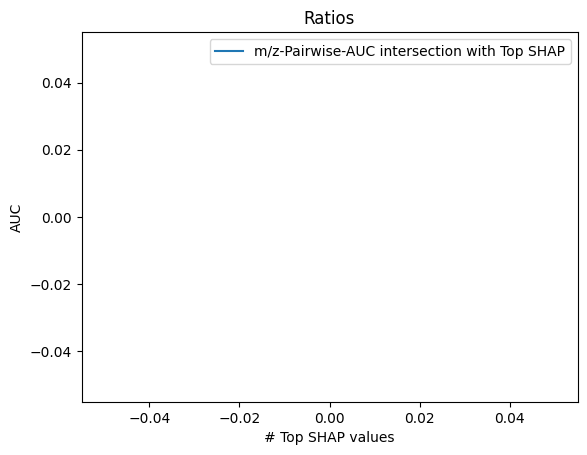

In [23]:
data = result_mean
ratios = [x[0] for x in data.values()]
ks = list(data.keys())

print(ratios)

plt.plot(ks, ratios, label="m/z-Pairwise-AUC intersection with Top SHAP")
plt.ylabel("AUC")
plt.xlabel("# Top SHAP values")
plt.legend()
plt.title("Ratios")
plt.show()


In [56]:
top_bayes_mzs = joblib.load("bayes_mzs.joblib")

auc_mzs = joblib.load("auc_mzs.joblib")


both = auc_mzs["unique"]["PLQ_ARTEFACT_ARTEFACT"] + auc_mzs["common"]["PLQ_ARTEFACT_ARTEFACT"]
auc_mzs = sorted(both, key = lambda x: x[1], reverse=True)[:50]
auc_mzs = [x[0] for x in auc_mzs]

print(auc_mzs)
print(top_bayes_mzs["PLQ_ARTEFACT_ARTEFACT"][: 50])

[1207.75938587, 480.30869475, 1180.73943434, 1207.78445573, 1181.74247752, 540.0534138, 865.50307848, 866.50730465, 795.51954846, 1179.73081311, 857.51706004, 857.517149, 690.50717159, 858.51944986, 1179.77816664, 858.52058908, 859.52412677, 855.55613631, 1180.77183556, 817.50718178, 866.47068285, 1003.47066935, 910.51133826, 849.50324067, 307.11567249, 746.56477652, 818.51091504, 822.52186156, 777.527129, 842.5178884, 943.50723857, 505.2825951, 1181.77444176, 987.49860265, 888.5585549, 888.5595747, 360.97134223, 1181.71779238, 889.56157921, 863.52114061, 820.46532839, 988.50056131, 600.51214678, 844.52988904, 793.5161795, 987.53393326, 808.07277013, 360.94226871]
[885.54829752, 885.55444354, 886.55296545, 857.517149, 857.51706004, 887.55554101, 858.52058908, 883.53274826, 858.51944986, 658.85612769, 834.5282567, 909.54899223, 882.5276895, 884.53634704, 881.51653566, 865.50307848, 888.5595747, 888.5585549, 859.52412677, 1179.73081311, 910.55275137, 882.530108, 540.0534138, 1180.7394343

In [5]:
import joblib
auc_mzs = joblib.load("auc_mzs.joblib")
bayesian_mzs = joblib.load("bayes_mzs.joblib")



categories = auc_mzs["unique"].keys()
indices_per_category = {}
bayesian_indices_per_category = {}
for category in categories:
    if category not in list(label_encoder.classes_):
        continue
    data = auc_mzs["unique"][category] + auc_mzs["common"][category]
    mzs = [x[0] for x in sorted(data, key = lambda x: x[1], reverse=True)]
    
    label = label_encoder.transform([category])[0]
    indices_per_category[label] = [extraction_mzs.index(mz) for mz in mzs]
    bayesian_indices_per_category[label] = [extraction_mzs.index(mz) for mz in bayesian_mzs[category]]

c:\Users\PahnkeLab\miniconda3\envs\maldi\Lib\site-packages\sklearn\metrics\_scorer.py:610: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(


48 48


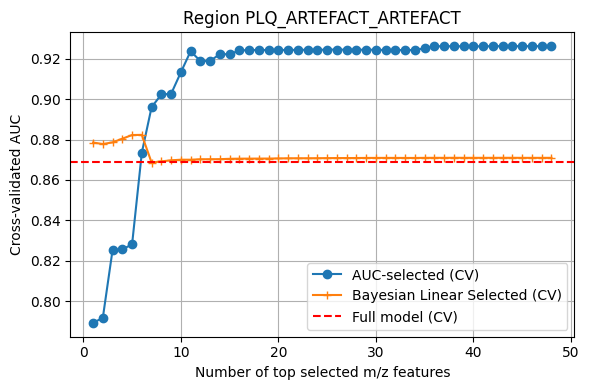

In [12]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, make_scorer
from sklearn.model_selection import StratifiedKFold, cross_val_score
import matplotlib.pyplot as plt


def compare_auc_vs_logreg_cv(X, y, auc_indices, bayes_indices, max_k=100, region_labels=None, cv_folds=5):
    if region_labels is None:
        region_labels = np.unique(y)

    results = {}


    for region_label in region_labels:
        
        if "PLQ" not in label_encoder.classes_[region_label]:
           continue
        #print(f"\n🔍 Region: {label_encoder.classes_[region_label]}")
        y_bin = (y == region_label).astype(int)

        skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
        auc_scorer = make_scorer(roc_auc_score, needs_proba=True)

        # 1. Full model
        clf_full = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000)
        full_auc_scores = cross_val_score(clf_full, X, y_bin, cv=skf, scoring=auc_scorer)
        full_auc_mean = np.mean(full_auc_scores)
        #print(f"  AUC (full model): {full_auc_mean:.4f}")

        # 2. AUC-selected features
        auc_list = []
        k_vals = list(range(1, min(max_k, len(auc_indices[region_label])) + 1))


        bayes_auc_list = []
        bayes_k_vals = list(range(1, min(len(k_vals), len(bayes_indices[region_label])) + 1))

        print(len(k_vals), len(bayes_k_vals))
        S = 1
        for k in k_vals[::S]:
            top_idx = auc_indices[region_label][:k]
            X_subset = X[:, top_idx]

            clf_k = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000)
            auc_scores = cross_val_score(clf_k, X_subset, y_bin, cv=skf, scoring=auc_scorer)
            auc_list.append(np.mean(auc_scores))

        for k in bayes_k_vals[::S]:
            top_idx = bayes_indices[region_label][:k]
            X_subset = X[:, top_idx]

            clf_k = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000)
            auc_scores = cross_val_score(clf_k, X_subset, y_bin, cv=skf, scoring=auc_scorer)
            bayes_auc_list.append(np.mean(auc_scores))


        results[label_encoder.classes_[region_label]] = {
            "full_auc": full_auc_mean,
            "k": k_vals,
            "auc_per_k": auc_list,
            "bayes_auc_per_k": bayes_auc_list
        }

        # 3. Plot
        plt.figure(figsize=(6, 4))
        plt.plot(k_vals[::S], auc_list, label="AUC-selected (CV)", marker='o')
        plt.plot(k_vals[::S], bayes_auc_list, label="Bayesian Linear Selected (CV)", marker='+')
        plt.axhline(full_auc_mean, color='red', linestyle='--', label="Full model (CV)")
        plt.xlabel("Number of top selected m/z features")
        plt.ylabel("Cross-validated AUC")
        plt.title(f"Region {label_encoder.classes_[region_label]}")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return results


results = compare_auc_vs_logreg_cv(X, y, indices_per_category, bayesian_indices_per_category, max_k=100)

In [88]:
joblib.dump(results, "feature_selection_crossval.joblib")

['feature_selection_crossval.joblib']

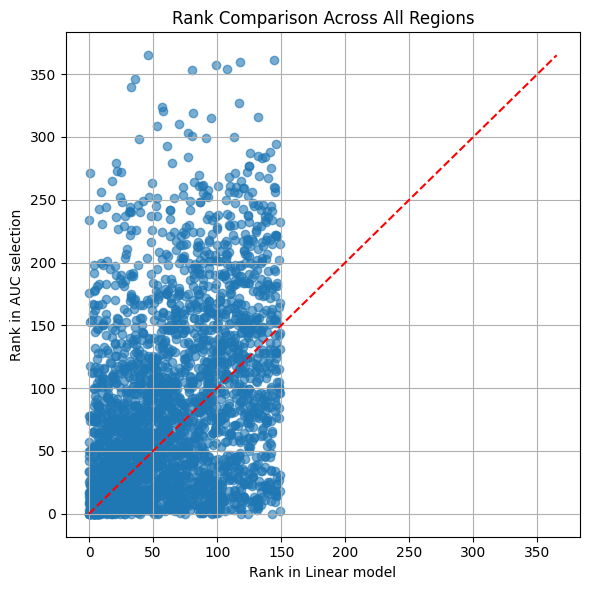

In [14]:
def scatter_rank_comparison_all_regions(source1, source2):
    """
    Compare rankings across all regions: scatter plot of ranks in source1 vs source2.
    Assumes source1 and source2 are dicts: {region: list of m/z values (ranked highest to lowest)}
    """
    all_x, all_y = [], []

    for region in source1:
        if region not in source2:
            continue

        mz_list1 = source1[region]
        mz_list2 = source2[region]
        common_mz = set(mz_list1) & set(mz_list2)

        # Compute ranks (0 = best)
        rank1 = {mz: i for i, mz in enumerate(mz_list1)}
        rank2 = {mz: i for i, mz in enumerate(mz_list2)}

        for mz in common_mz:
            all_x.append(rank1[mz])
            all_y.append(rank2[mz])

    if not all_x:
        print("No common m/z values across any regions.")
        return

    plt.figure(figsize=(6, 6))
    plt.scatter(all_x, all_y, alpha=0.6)
    plt.plot([min(all_x + all_y), max(all_x + all_y)], [min(all_x + all_y), max(all_x + all_y)], 'r--')
    plt.xlabel("Rank in Linear model")
    plt.ylabel("Rank in AUC selection")
    plt.title("Rank Comparison Across All Regions")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

scatter_rank_comparison_all_regions(bayesian_indices_per_category, indices_per_category)


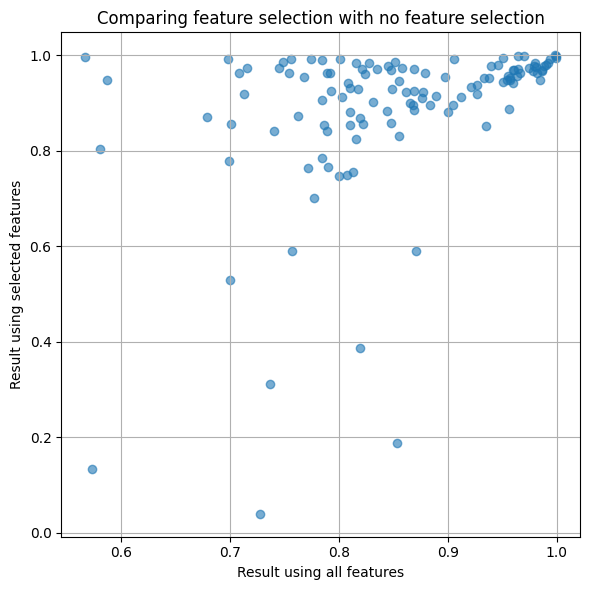

In [22]:
results = joblib.load("feature_selection_crossval.joblib")
fulls, selected = [], []
for region in results:
    full_auc = results[region]["full_auc"]
    N = len(results[region]["auc_per_k"]) - 1
    if N == -1:
        continue
    N = min(N, 50)
    feature_selection = results[region]["auc_per_k"][N]
    fulls.append(full_auc)
    selected.append(feature_selection)

plt.figure(figsize=(6, 6))
plt.scatter(fulls, selected, alpha=0.6)
#plt.plot([min(all_x + all_y), max(all_x + all_y)], [min(all_x + all_y), max(all_x + all_y)], 'r--')
plt.xlabel("Result using all features")
plt.ylabel("Result using selected features")
plt.title("Comparing feature selection with no feature selection")
plt.grid(True)
plt.tight_layout()
plt.show()